In this section, you will learn how to:

- understand how problem graphs are mapped into the analog Rydberg model through embedding,
- use QoolQit embedders to embed graphs, i.e. assigning coordinates to nodes,
- test whether an embedding satisfies hardware constraints (e.g. unit-disk condition),
- convert embedded graphs into qubit registers.

---

## The embedding problem

Embedding data and problems into the Rydberg analog model is an active area of research. An embedding is typically defined as a structure-preserving mapping $f_\text{embedding}: X \rightarrow Y$ that transforms an object $X$ into an object $Y$. In our context, we seek to develop effective embedding functions that map problem-specific data and structures into representations compatible with the Rydberg analog model.

Currently, QoolQit focuses on register embedders - algorithms that assign coordinates to graph nodes, enabling the creation of qubit registers from abstract graph structures.

In QoolQit, all embedders follow a basic interface. For example, the `InteractionEmbedder` (discussed in detail later) interface provides the following methods:

```python
from qoolqit import InteractionEmbedder, InteractionEmbedderConfig

# Initialize the embedder
config = InteractionEmbedderConfig()
embedder = InteractionEmbedder(config=config)

# Access information about the embedding algorithm
embedder.info

# Access the configuration of the embedding algorithm
embedder.config

# Embed the data with the embedder
embedded_data = embedder.embed(data)
```

All the available embedders are listed in following section. For more details on defining custom embedders, the reader can refer to [Custom embedders](../extended_usage/custom_embedders.ipynb).

## Available embedders
Below, we will exemplify how to use some of the pre-defined concrete embedders directly available in QoolQit, and then show some considerations when defining custom embedders.

### Interaction embedder
Interaction embedding means to encode a matrix in the interaction term of the Rydberg analog model. For a matrix $U$, the goal is to find the set of coordinates that minimize

$$
\min_{\{(x,\, y)\}}~\sum_{ij}\left\|U_{ij}-\frac{1}{r^6_{ij}}\right\|,
$$

where $r_{ij} = \sqrt{(x_i-x_j)^2 + (y_i-y_j)^2}$ is the distance between qubits $i$ and $j$. This requires the matrix $U$ to be positive and symmetric, and only the off-diagonal terms are embedded.

In QoolQit, the `InteractionEmbedder` performs this minimization using `scipy.minimize`, and it maps a `np.ndarray` to a `DataGraph` with coordinates.

In [1]:
from qoolqit.embedding import InteractionEmbedder

embedder = InteractionEmbedder()
print(embedder)

InteractionEmbedder:
| Algorithm: interaction_embedding
| Config: InteractionEmbedderConfig(method='Nelder-Mead', maxiter=200000, tol=1e-08, x0=None)


Checking the `info` on the embedder, we see a few parameters are available for customization through the `config`. There are parameters that get passed to `scipy.minimize`, and their description can be found in the [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html).

In [2]:
print(embedder.info)

-- Embedding algorithm docstring:

Matrix embedding into the interaction term of the Rydberg Analog Model.

Uses scipy.minimize to find the optimal set of node coordinates such that the
matrix of values 1/(r_ij)^6 approximate the off-diagonal terms of the input matrix.

Check the documentation for scipy.minimize for more information about each parameter:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

Arguments:
    matrix: the matrix to embed.
    method: the method used by scipy.minimize.
    x0: starting positions.
    maxiter: maximum number of iterations.
    tol: tolerance for termination.


We can try it out with the default configuration by generating a random symmetric positive matrix.

In [3]:
import numpy as np

A = np.random.rand(6, 6)
A += A.T
print(A)

[[1.38258855 0.95354558 0.69533663 0.72782654 1.0204611  1.04837576]
 [0.95354558 0.84839892 1.37134904 1.07373882 0.72045249 0.90679915]
 [0.69533663 1.37134904 0.53123258 0.43863606 0.6591137  0.92265948]
 [0.72782654 1.07373882 0.43863606 0.40773696 0.83069805 0.59011741]
 [1.0204611  0.72045249 0.6591137  0.83069805 1.31639637 0.94139737]
 [1.04837576 0.90679915 0.92265948 0.59011741 0.94139737 0.86959804]]


Finally, running the embedding we obtain a `DataGraph` with coordinates that can be easily converted to a `Register` of qubits.

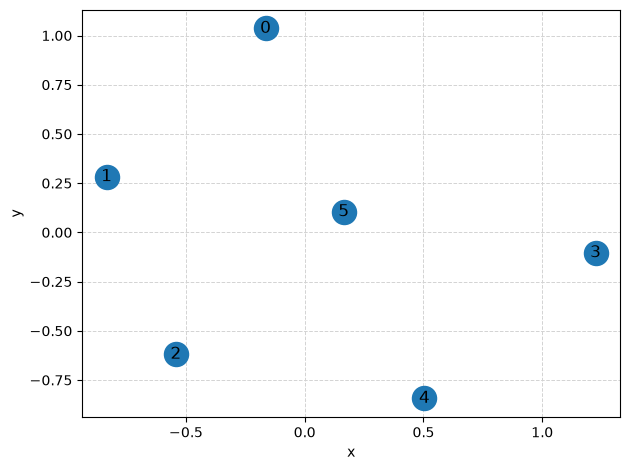

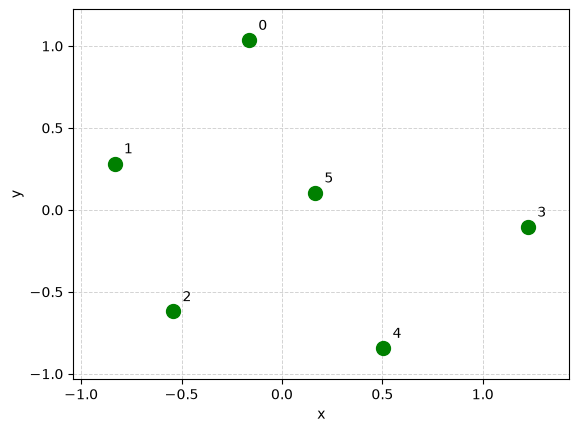

In [4]:
import matplotlib.pyplot as plt

from qoolqit import Register

embedded_graph = embedder.embed(A)
register = Register.from_graph(embedded_graph)

embedded_graph.draw()
register.draw()

To check how the embedding performed, we can inspect the interaction values in the `Register` and compare them to the off-diagonal elements in the matrix.

In [5]:
interactions = list(register.interactions().values())

triang_upper = np.triu(A, k = 1)
off_diagonal = triang_upper[triang_upper != 0].tolist()

print([f"{f:.4f}" for f in sorted(interactions)])
print([f"{f:.4f}" for f in sorted(off_diagonal)])

['0.0119', '0.0159', '0.0258', '0.0297', '0.0350', '0.0418', '0.6298', '0.6665', '0.8266', '0.9193', '0.9349', '0.9567', '0.9612', '1.0760', '1.3787']
['0.4386', '0.5901', '0.6591', '0.6953', '0.7205', '0.7278', '0.8307', '0.9068', '0.9227', '0.9414', '0.9535', '1.0205', '1.0484', '1.0737', '1.3713']


### Spring-layout embedder

The spring-layout embedding utilizes the Fruchterman-Reingold force-directed algorithm. It assigns spring-like forces to the edges that keep nodes closer, while treating nodes themselves as repelling objects. The system is then simulated until the nodes find an equilibrium position, which represent the final coordinates assigned to the nodes.

In QoolQit, the `SpringLayoutEmbedder` directly wraps the `nx.spring_layout` function, and it maps a `DataGraph` without coordinates to another `DataGraph` with coordinates.

In [6]:
from qoolqit.embedding import SpringLayoutEmbedder

embedder = SpringLayoutEmbedder()
print(embedder)

SpringLayoutEmbedder:
| Algorithm: spring_layout_embedding
| Config: SpringLayoutConfig(iterations=100, threshold=0.0001, seed=None)


As you can see above it holds an algorithm and a config with a set of default parameters. For information on the algorithm and parameters, you can use the `embedder.info` property.

In [7]:
print(embedder.info)

-- Embedding algorithm docstring:

Force-directed embedding, wrapping `nx.spring_layout`.

Generates a new graph with the same nodes and edges as the original graph, but with
node coordinates set to embed edge weights into pairwise distances as wᵢⱼ=1/rᵢⱼ^6.

The positions are generated by `nx.spring_layout`.
Since `nx.spring_layout` embeds edge weights as wᵢⱼ = (k/rᵢⱼ)^3, we set:
 - `k=1` and `scale=None` to disable global rescaling of positions.
 - rescale weights wᵢⱼ -> wᵢⱼ^1/2
to achieve our target embedding wᵢⱼ=1/rᵢⱼ^6.

Check the documentation for `nx.spring_layout` for more information about each parameter:
https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html

Args:
    graph: the graph to embed according to its edge weights.
    iterations: maximum number of iterations to take.
    threshold: Threshold for relative error in node position changes.
        The iteration stops if force-displacement is below this threshold.
    see

In this case, the embedder is a direct wrapper on top of `nx.spring_layout`, and any parameters are the ones directly used by that function. For more information, you can check the [documentation for NetworkX](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html). The parameters can be directly changed in the config.

In [8]:
embedder.config.iterations = 100
embedder.config.seed = 1
print(embedder)

SpringLayoutEmbedder:
| Algorithm: spring_layout_embedding
| Config: SpringLayoutConfig(iterations=100, threshold=0.0001, seed=1)


Finally, we can run the embedder with the `embed` method.

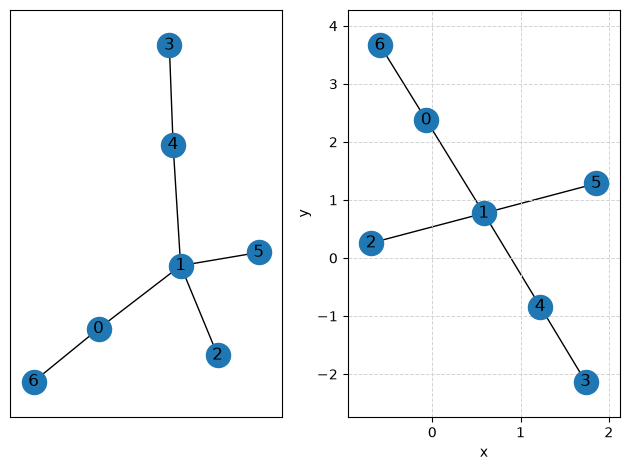

In [9]:
from qoolqit import DataGraph

graph_1 = DataGraph.random_er(n = 7, p = 0.3, seed = 3)
embedded_graph_1 = embedder.embed(graph_1)

fig, axs = plt.subplots(1, 2)
graph_1.draw(ax=axs[0])
embedded_graph_1.draw(ax=axs[1])

Now, we can check if the resulting graph is a unit-disk graph.

In [10]:
embedded_graph_1.is_ud_graph()

True

In this case, the embedding was successful and we obtained a unit-disk graph. For more densely connected graphs, the spring layout algorithm tends to struggle with finding a unit-disk graph embedding, if it even exists.

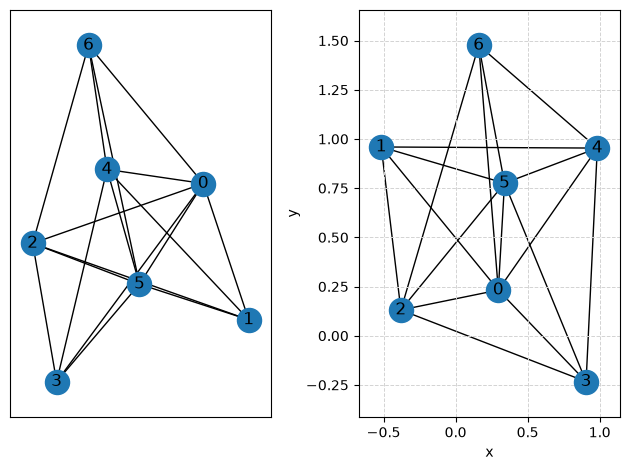

In [11]:
graph_2 = DataGraph.random_er(n = 7, p = 0.8, seed = 3)
embedded_graph_2 = embedder.embed(graph_2)

fig, axs = plt.subplots(1, 2)
graph_2.draw(ax=axs[0])
embedded_graph_2.draw(ax=axs[1])

While the algorithm converged and assigned positions to each node, the resulting embedded graph fails the unit-disk graph test.

However, in both cases, we have embedded the original data into a graph with coordinates, which is an object that is compatible with the Rydberg analog model. As such, we can directly instantiate a register of qubits from these graphs.

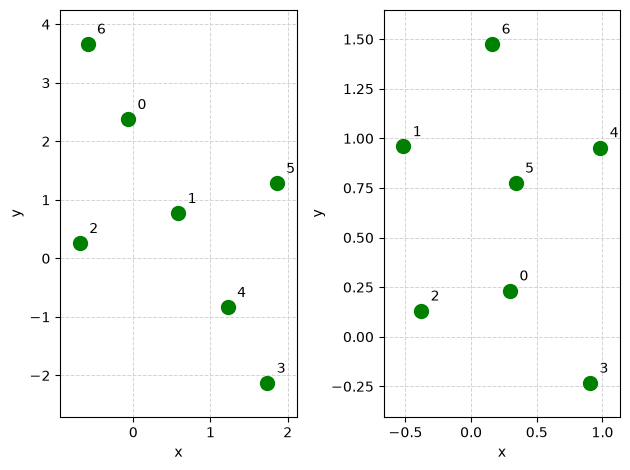

In [12]:
from qoolqit import Register

register_1 = Register.from_graph(embedded_graph_1)
register_2 = Register.from_graph(embedded_graph_2)

fig, axs = plt.subplots(1, 2)
register_1.draw(ax=axs[0])
register_2.draw(ax=axs[1])
fig.tight_layout()

While defining a graph, weights can also be directly assigned to edges.

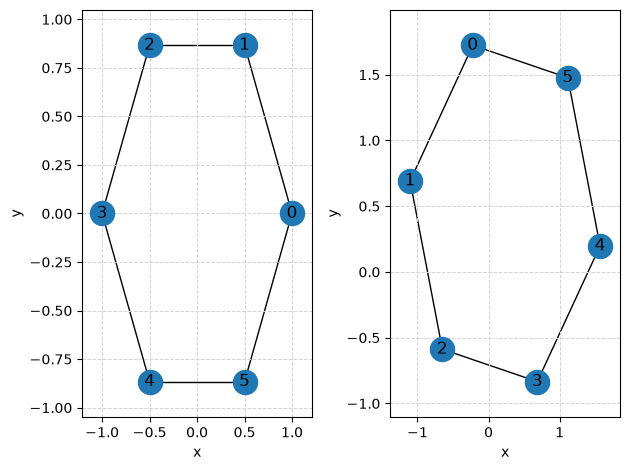

In [13]:
n=6
graph_2 = DataGraph.circle(n)
for i,e in enumerate(graph_2.edge_weights):
    graph_2.edge_weights[e]= np.random.rand()

embedded_graph_2 = embedder.embed(graph_2)

fig, axs = plt.subplots(1, 2)
graph_2.draw(ax=axs[0])
embedded_graph_2.draw(ax=axs[1])

The embedder will respect the edge weights, ensuring that edges with higher weights are closer in the embedded graph.

### Blade
Coming soon...